<a href="https://colab.research.google.com/github/emilheroyt/Bachelor-Thesis-Stress-Testing-Robustness-of-SOTA-Point-Trackers/blob/main/tapnext_demoIsolation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title Install Code and Dependencies {form-width: "25%"}
!pip install git+https://github.com/google-deepmind/tapnet.git
!pip install -U flax

  Cloning https://github.com/google-deepmind/tapnet.git to /tmp/pip-req-build-mbr5eq_i
  Running command git clone --filter=blob:none --quiet https://github.com/google-deepmind/tapnet.git /tmp/pip-req-build-mbr5eq_i
  Resolved https://github.com/google-deepmind/tapnet.git to commit c2cbab81cc06092b5f05bfe2da7bfec54e2079c9
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━

In [ ]:
# @title Download Model {form-width: "25%"}

%mkdir -p tapnet/checkpoints
!wget -P tapnet/checkpoints --no-check-certificate https://storage.googleapis.com/dm-tapnet/tapnext/bootstapnext_ckpt.npz
%ls tapnet/checkpoints

--2026-09-03 20:54:52--  https://storage.googleapis.com/dm-tapnet/tapnext/bootstapnext_ckpt.npz
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.79.207, 172.253.154.207, 192.178.213.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.79.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 776980182 (741M) [application/octet-stream]
Saving to: ‘tapnet/checkpoints/bootstapnext_ckpt.npz’

bootstapnext_ckpt.n 100%[===================>] 740.99M  36.4MB/s    in 20s     

2026-09-03 20:55:13 (36.4 MB/s) - ‘tapnet/checkpoints/bootstapnext_ckpt.npz’ saved [776980182/776980182]

bootstapnext_ckpt.npz


In [ ]:
# @title Base Imports {form-width: "10%"}

import io
import os

import cv2
import einops
import flax.linen as nn
import jax
import jax.nn as jnn
import jax.numpy as jnp
import matplotlib
import mediapy as media
import numpy as np
from tapnet import evaluation_datasets

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/co

In [ ]:
# @title Base Layers {form-width: "25%"}


class MlpBlock(nn.Module):

  @nn.compact
  def __call__(self, x):
    d = x.shape[-1]
    x = nn.gelu(nn.Dense(4 * d)(x))
    return nn.Dense(d)(x)


class ViTBlock(nn.Module):
  num_heads: int = 12

  @nn.compact
  def __call__(self, x):
    y = nn.LayerNorm()(x)
    y = nn.MultiHeadDotProductAttention(num_heads=self.num_heads)(y, y)
    x = x + y
    y = nn.LayerNorm()(x)
    y = MlpBlock()(y)
    x = x + y
    return x


class Einsum(nn.Module):
  width: int = 768

  def setup(self):
    self.w = self.param(
        "w", nn.initializers.zeros_init(), (2, self.width, self.width * 4)
    )
    self.b = self.param(
        "b", nn.initializers.zeros_init(), (2, 1, 1, self.width * 4)
    )[:, 0]

  def __call__(self, x):
    return jnp.einsum("...d,cdD->c...D", x, self.w) + self.b


class RMSNorm(nn.Module):
  width: int = 768

  def setup(self):
    self.scale = self.param("scale", nn.initializers.zeros_init(), (self.width))

  def __call__(self, x):
    var = jnp.mean(jnp.square(x), axis=-1, keepdims=True)
    normed_x = x * jax.lax.rsqrt(var + 1e-6)
    scale = jnp.expand_dims(self.scale, axis=range(len(x.shape) - 1))
    return normed_x * (scale + 1)


class Conv1D(nn.Module):
  width: int = 768
  kernel_size: int = 4

  def setup(self):
    self.w = self.param(
        "w", nn.initializers.zeros_init(), (self.kernel_size, self.width)
    )
    self.b = self.param("b", nn.initializers.zeros_init(), (self.width))

  def __call__(self, x, state):
    if state is None:
      state = jnp.zeros(
          (x.shape[0], self.kernel_size - 1, x.shape[1]), dtype=x.dtype
      )
    x = jnp.concatenate([state, x[:, None]], axis=1)  # shape: (b, k, c)
    out = (x * self.w[None]).sum(axis=-2) + self.b[None]  # shape: (b, c)
    state = x[:, 1 - self.kernel_size :]  # shape: (b, k - 1, c)
    return out, state


class BlockDiagonalLinear(nn.Module):
  width: int = 768
  num_heads: int = 12

  def setup(self):
    width = self.width // self.num_heads
    self.w = self.param(
        "w", nn.initializers.zeros_init(), (self.num_heads, width, width)
    )
    self.b = self.param(
        "b", nn.initializers.zeros_init(), (self.num_heads, width)
    )

  def __call__(self, x):
    x = einops.rearrange(x, "... (h i) -> ... h i", h=self.num_heads)
    y = jnp.einsum("... h i, h i j -> ... h j", x, self.w) + self.b
    return einops.rearrange(y, "... h j -> ... (h j)", h=self.num_heads)


class RGLRU(nn.Module):
  width: int = 768
  num_heads: int = 12

  def setup(self):
    self.a_real_param = self.param(
        "a_param", nn.initializers.zeros_init(), (self.width)
    )
    self.input_gate = BlockDiagonalLinear(
        self.width, self.num_heads, name="input_gate"
    )
    self.a_gate = BlockDiagonalLinear(self.width, self.num_heads, name="a_gate")

  def __call__(self, x, state):
    gate_x = jnn.sigmoid(self.input_gate(x))
    if state is None:
      return gate_x * x  # No memory accumulation, return directly
    else:
      gate_a = jnn.sigmoid(self.a_gate(x))
      log_a = -8.0 * gate_a * jnn.softplus(self.a_real_param)
      a = jnp.exp(log_a)
      scale_factor = jnp.sqrt(1 - jnp.exp(2 * log_a))  # Compute decay factor
      return a * state + gate_x * x * scale_factor  # Memory update

In [ ]:
# @title ViTSSM Blocks {form-width: "25%"}


class MLPBlock(nn.Module):
  width: int = 768

  def setup(self):
    self.ffw_up = Einsum(self.width, name="ffw_up")
    self.ffw_down = nn.Dense(self.width, name="ffw_down")

  def __call__(self, x):
    out = self.ffw_up(x)
    return self.ffw_down(nn.gelu(out[0]) * out[1])


class RecurrentBlock(nn.Module):
  width: int = 768
  num_heads: int = 12
  kernel_size: int = 4

  def setup(self) -> None:
    self.linear_y = nn.Dense(self.width, name="linear_y")
    self.linear_x = nn.Dense(self.width, name="linear_x")
    self.conv_1d = Conv1D(self.width, self.kernel_size, name="conv_1d")
    self.lru = RGLRU(self.width, self.num_heads, name="rg_lru")
    self.linear_out = nn.Dense(self.width, name="linear_out")

  def __call__(self, x, state):
    y = jax.nn.gelu(self.linear_y(x))
    x = self.linear_x(x)
    x, conv1d_state = self.conv_1d(
        x, None if state is None else state["conv1d_state"]
    )
    rg_lru_state = self.lru(x, None if state is None else state["rg_lru_state"])
    x = self.linear_out(rg_lru_state * y)
    return x, {"rg_lru_state": rg_lru_state, "conv1d_state": conv1d_state}


class ResidualBlock(nn.Module):
  width: int = 768
  num_heads: int = 12
  kernel_size: int = 4

  def setup(self):
    self.temporal_pre_norm = RMSNorm(self.width)
    self.recurrent_block = RecurrentBlock(
        self.width, self.num_heads, self.kernel_size, name="recurrent_block"
    )
    self.channel_pre_norm = RMSNorm(self.width)
    self.mlp = MLPBlock(self.width, name="mlp_block")

  def __call__(self, x, state):
    y = self.temporal_pre_norm(x)
    y, state = self.recurrent_block(y, state)
    x = x + y
    y = self.mlp(self.channel_pre_norm(x))
    x = x + y
    return x, state


class ViTSSMBlock(nn.Module):
  width: int = 768
  num_heads: int = 12
  kernel_size: int = 4

  def setup(self):
    self.ssm_block = ResidualBlock(self.width, self.num_heads, self.kernel_size)
    self.vit_block = ViTBlock(self.num_heads)

  def __call__(self, x, state):
    b = x.shape[0]
    x = einops.rearrange(x, "b n c -> (b n) c")
    x, state = self.ssm_block(x, state)
    x = einops.rearrange(x, "(b n) c -> b n c", b=b)
    x = self.vit_block(x)
    return x, state


class ViTSSMBackbone(nn.Module):
  width: int = 768
  num_heads: int = 12
  kernel_size: int = 4
  num_blocks: int = 12

  def setup(self):
    self.blocks = [
        ViTSSMBlock(
            self.width,
            self.num_heads,
            self.kernel_size,
            name=f"encoderblock_{i}",
        )
        for i in range(self.num_blocks)
    ]
    self.encoder_norm = nn.LayerNorm()

  def __call__(self, x, state):
    new_states = []
    for i in range(self.num_blocks):
      x, new_state = self.blocks[i](x, None if state is None else state[i])
      new_states.append(new_state)
    x = self.encoder_norm(x)
    return x, new_states

In [ ]:
# @title TAPNext Model {form-width: "25%"}


def posemb_sincos_2d(h, w, width):
  """Compute 2D sine-cosine positional embeddings following MoCo v3 logic."""
  y, x = jnp.mgrid[0:h, 0:w]
  freqs = jnp.linspace(0, 1, num=width // 4, endpoint=True)
  inv_freq = 1.0 / (10_000**freqs)
  y = jnp.einsum("h w, d -> h w d", y, inv_freq)
  x = jnp.einsum("h w, d -> h w d", x, inv_freq)
  pos_emb = jnp.concatenate(
      [jnp.sin(x), jnp.cos(x), jnp.sin(y), jnp.cos(y)], axis=-1
  )
  return pos_emb


class Backbone(nn.Module):
  width: int = 768
  num_heads: int = 12
  kernel_size: int = 4
  num_blocks: int = 12

  def setup(self):
    self.lin_proj = nn.Conv(
        self.width,
        (1, 8, 8),
        strides=(1, 8, 8),
        padding="VALID",
        name="embedding",
    )
    self.mask_token = self.param(
        "mask_token", nn.initializers.zeros_init(), (1, 1, 1, self.width)
    )[:, 0]
    self.unknown_token = self.param(
        "unknown_token", nn.initializers.zeros_init(), (1, 1, self.width)
    )
    self.point_query_token = self.param(
        "point_query_token", nn.initializers.zeros_init(), (1, 1, 1, self.width)
    )[:, 0]
    self.image_pos_emb = self.param(
        "pos_embedding",
        nn.initializers.zeros_init(),
        (1, 256 // 8 * 256 // 8, self.width),
    )
    self.encoder = ViTSSMBackbone(
        self.width,
        self.num_heads,
        self.kernel_size,
        self.num_blocks,
        name="Transformer",
    )

  def __call__(self, frame, query_points, step, state):
    x = self.lin_proj(frame)  # x: (b, h, w, c)
    b, h, w, c = x.shape
    query_points = jnp.concatenate(
        [query_points[..., :1] - step, query_points[..., 1:]], axis=-1
    )  # (b, q, 3)
    posemb2d = posemb_sincos_2d(256, 256, self.width)  # posemb2d: (256, 256, c)

    def interp(x, y):
      return jax.scipy.ndimage.map_coordinates(
          x, y.T - 0.5, order=1, mode="nearest"
      )

    interp_fn = jax.vmap(interp, in_axes=(-1, None), out_axes=-1)
    interp_fn = jax.vmap(interp_fn, in_axes=(None, 0), out_axes=0)
    point_tokens = self.point_query_token + interp_fn(
        posemb2d, query_points[..., 1:]
    )  # (b, q, c)
    # Query tokens
    query_timesteps = query_points[..., 0:1].astype(jnp.int32)  # (b, q, 1)
    query_tokens = jnp.where(
        query_timesteps > 0, self.unknown_token, self.mask_token
    )  # (b, q, c)
    query_tokens = jnp.where(
        query_timesteps == 0, point_tokens, query_tokens
    )  # (b, q, c)
    # Image tokens
    image_tokens = (
        jnp.reshape(x, [b, h * w, c]) + self.image_pos_emb
    )  # x: (b, h*w, c)

    x = jnp.concatenate(
        [image_tokens, query_tokens], axis=-2
    )  # x: (b, h*w + q, c)
    x, state = self.encoder(x, state)
    _, q, _ = query_points.shape
    x = x[:, -q:, :]  # x: (b, q, c)

    return x, state


def get_window(coord, softmax, radius=6):
  """Note: coord is assumed to be a raster coordinate."""
  start = jnp.maximum(jnp.array(jnp.floor(coord - radius - 0.5), jnp.int32), 0)
  softmax = jax.lax.dynamic_slice(softmax, [start], [radius * 2 + 1])
  coord = start + 0.5 + jnp.arange(radius * 2 + 1)
  return softmax, coord


def get_uncertainty(coord_yx, track_logits, radius=6):
  """Get uncertainty from coordinate logits for a single point/frame."""
  logits_y, logits_x = jnp.split(track_logits, 2, axis=-1)
  track_softmax_y = jax.nn.softmax(logits_y)
  track_softmax_x = jax.nn.softmax(logits_x)
  sm_y, coord_y = get_window(coord_yx[0], track_softmax_y)
  sm_x, coord_x = get_window(coord_yx[1], track_softmax_x)
  sm = sm_y[:, jnp.newaxis] * sm_x[jnp.newaxis, :]
  grid_x, grid_y = jnp.meshgrid(coord_x, coord_y)
  grid = jnp.stack([grid_y, grid_x], axis=-1)
  in_radius = (
      jnp.sum(jnp.square(grid - coord_yx), axis=-1) <= jnp.square(radius) + 1e-8
  )
  return jnp.sum(sm * in_radius)


def tracker_uncertainty(tracks, track_logits):
  """Get uncertainty for all points/frames in a batch."""
  vmapped_uncertain_fn = get_uncertainty
  for _ in range(len(tracks.shape) - 1):
    vmapped_uncertain_fn = jax.vmap(vmapped_uncertain_fn)
  uncertainty = vmapped_uncertain_fn(tracks, track_logits)
  return uncertainty[..., jnp.newaxis]


class TAPNext(nn.Module):
  width: int = 768
  num_heads: int = 12
  kernel_size: int = 4
  num_blocks: int = 12
  use_certainty: bool = True

  def setup(self):
    self.backbone = Backbone(
        self.width, self.num_heads, self.kernel_size, self.num_blocks
    )
    self.visible_head = nn.Sequential([
        nn.Dense(256),
        nn.LayerNorm(),
        nn.gelu,
        nn.Dense(256),
        nn.LayerNorm(),
        nn.gelu,
        nn.Dense(1),
    ])
    self.coordinate_head = nn.Sequential([
        nn.Dense(256),
        nn.LayerNorm(),
        nn.gelu,
        nn.Dense(256),
        nn.LayerNorm(),
        nn.gelu,
        nn.Dense(512),
    ])

  @nn.compact
  def __call__(self, frame, query_points, step, state):
    feat, state = self.backbone(frame, query_points, step, state)
    track_logits = self.coordinate_head(feat)
    visible_logits = self.visible_head(feat)

    position_x, position_y = jnp.split(track_logits, 2, axis=-1)
    position = jnp.stack([position_x, position_y], axis=-2)
    index = jnp.arange(position.shape[-1])[None, None, None]
    argmax = jnp.argmax(position, axis=-1, keepdims=True)
    mask = jnp.abs(argmax - index) <= 20
    probs = jnn.softmax(position * 0.5, axis=-1) * mask
    probs = probs / jnp.sum(probs, axis=-1, keepdims=True)
    tracks = jnp.sum(probs * index, axis=-1) + 0.5

    if self.use_certainty:
      certain = tracker_uncertainty(tracks, track_logits)
      visible = ((jax.nn.sigmoid(visible_logits) * certain) > 0.5).astype(
          jnp.float32
      )
    else:
      visible = (visible_logits > 0).astype(jnp.float32)
    return tracks, visible, state


model = TAPNext()


@jax.jit
def forward(params, frame, query_points, step, state):
  tracks, visible, state = model.apply(
      {"params": params}, frame, query_points, step, state
  )
  return tracks, visible, state

In [ ]:
# @title Load parameters {form-width: "25%"}


def npload(fname):
  if os.path.exists(fname):
    loaded = np.load(fname, allow_pickle=False)
  else:
    with open(fname, "rb") as f:
      data = f.read()
    loaded = np.load(io.BytesIO(data), allow_pickle=False)
  if isinstance(loaded, np.ndarray):
    return loaded
  else:
    return dict(loaded)


def recover_tree(flat_dict):
  tree = (
      {}
  )  # Initialize an empty dictionary to store the resulting tree structure
  for (
      k,
      v,
  ) in (
      flat_dict.items()
  ):  # Iterate over each key-value pair in the flat dictionary
    parts = k.split(
        "/"
    )  # Split the key into parts using "/" as a delimiter to build the tree structure
    node = tree  # Start at the root of the tree
    for part in parts[
        :-1
    ]:  # Loop through each part of the key, except the last one
      if (
          part not in node
      ):  # If the current part doesn't exist as a key in the node, create an empty dictionary for it
        node[part] = {}
      node = node[part]  # Move down the tree to the next level
    node[parts[-1]] = v  # Set the value at the final part of the key
  return tree  # Return the reconstructed tree


ckpt_path = "tapnet/checkpoints/bootstapnext_ckpt.npz"
params = recover_tree(npload(ckpt_path))

In [ ]:
# @title Visualization function {form-width: "25%"}


def plot_2d_tracks(
    video,
    points,
    visibles,
    infront_cameras=None,
    tracks_leave_trace=16,
    show_occ=False,
):
  """Visualize 2D point trajectories."""
  num_frames, num_points = points.shape[:2]

  # Precompute colormap for points
  color_map = matplotlib.colormaps.get_cmap('hsv')
  cmap_norm = matplotlib.colors.Normalize(vmin=0, vmax=num_points - 1)
  point_colors = np.zeros((num_points, 3))
  for i in range(num_points):
    point_colors[i] = (np.array(color_map(cmap_norm(i)))[:3] * 255).astype(
        np.uint8
    )

  if infront_cameras is None:
    infront_cameras = np.ones_like(visibles).astype(bool)

  frames = []
  for t in range(num_frames):
    frame = video[t].copy()

    # Draw tracks on the frame
    line_tracks = points[max(0, t - tracks_leave_trace) : t + 1]
    line_visibles = visibles[max(0, t - tracks_leave_trace) : t + 1]
    line_infront_cameras = infront_cameras[
        max(0, t - tracks_leave_trace) : t + 1
    ]
    for s in range(line_tracks.shape[0] - 1):
      img = frame.copy()

      for i in range(num_points):
        if line_visibles[s, i] and line_visibles[s + 1, i]:  # visible
          x1, y1 = int(round(line_tracks[s, i, 0])), int(
              round(line_tracks[s, i, 1])
          )
          x2, y2 = int(round(line_tracks[s + 1, i, 0])), int(
              round(line_tracks[s + 1, i, 1])
          )
          cv2.line(frame, (x1, y1), (x2, y2), point_colors[i], 1, cv2.LINE_AA)
        elif (
            show_occ
            and line_infront_cameras[s, i]
            and line_infront_cameras[s + 1, i]
        ):  # occluded
          x1, y1 = int(round(line_tracks[s, i, 0])), int(
              round(line_tracks[s, i, 1])
          )
          x2, y2 = int(round(line_tracks[s + 1, i, 0])), int(
              round(line_tracks[s + 1, i, 1])
          )
          cv2.line(frame, (x1, y1), (x2, y2), point_colors[i], 1, cv2.LINE_AA)

      alpha = (s + 1) / (line_tracks.shape[0] - 1)
      frame = cv2.addWeighted(frame, alpha, img, 1 - alpha, 0)

    # Draw end points on the frame
    for i in range(num_points):
      if visibles[t, i]:  # visible
        x, y = int(round(points[t, i, 0])), int(round(points[t, i, 1]))
        cv2.circle(frame, (x, y), 3, point_colors[i], -1, cv2.LINE_AA)
      elif show_occ and infront_cameras[t, i]:  # occluded
        x, y = int(round(points[t, i, 0])), int(round(points[t, i, 1]))
        cv2.circle(frame, (x, y), 3, point_colors[i], 1, cv2.LINE_AA)

    frames.append(frame)
  frames = np.stack(frames)
  return frames

In [ ]:
# @title Download TAPVid-DAVIS Dataset {form-width: "25%"}
!wget --no-check-certificate https://storage.googleapis.com/dm-tapnet/tapvid_davis.zip
!unzip tapvid_davis.zip

--2026-09-03 20:55:19--  https://storage.googleapis.com/dm-tapnet/tapvid_davis.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.79.207, 172.253.154.207, 192.178.213.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.79.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1668710491 (1.6G) [application/zip]
Saving to: ‘tapvid_davis.zip’

tapvid_davis.zip    100%[===================>]   1.55G  35.5MB/s    in 46s     

2026-09-03 20:56:06 (34.3 MB/s) - ‘tapvid_davis.zip’ saved [1668710491/1668710491]

Archive:  tapvid_davis.zip
   creating: tapvid_davis/
  inflating: tapvid_davis/SOURCES.md  
  inflating: tapvid_davis/README.md  
  inflating: tapvid_davis/tapvid_davis.pkl  


In [ ]:
%%time
# @title Qualitative results on dense tracks

davis_dataset = evaluation_datasets.create_davis_dataset(
    davis_points_path='./tapvid_davis/tapvid_davis.pkl',
    query_mode='first',
    full_resolution=False,
    resolution=(256, 256),
)

for i, sample in enumerate(davis_dataset):
  frames = sample['davis']['video']
  ys, xs = np.meshgrid(np.linspace(8, 256, 32), np.linspace(8, 256, 32))
  query_points = np.stack(
      [np.zeros(len(xs.flatten())), xs.flatten(), ys.flatten()], axis=1
  )[None]

  tracks, visibles, state = [], [], None
  for t in range(0, frames.shape[1]):
    pred_tracks, pred_visible, state = forward(
        params, frames[:, t], query_points, t, state
    )
    tracks.append(pred_tracks)
    visibles.append(pred_visible)
  tracks = np.stack(tracks, axis=2)[..., ::-1]
  visibles = np.stack(visibles, axis=2).squeeze(-1)

  frames = ((frames[0] + 1) / 2 * 255).astype(np.uint8)
  video_viz = plot_2d_tracks(
      frames, tracks[0].transpose(1, 0, 2), visibles[0].transpose(1, 0)
  )
  media.show_video(video_viz, fps=15)

This browser does not support the video tag.


This browser does not support the video tag.


This browser does not support the video tag.


KeyboardInterrupt: 

In [ ]:
%%time
# @title Qualitative results on sparse tracks

davis_dataset = evaluation_datasets.create_davis_dataset(
    davis_points_path='./tapvid_davis/tapvid_davis.pkl',
    query_mode='first',
    full_resolution=False,
    resolution=(256, 256),
)

cnt = 0
for i, sample in enumerate(davis_dataset):
  batch = sample['davis']
  tracks, visibles, state = [], [], None
  for t in range(0, batch['video'].shape[1]):
    pred_tracks, pred_visible, state = forward(
        params, batch['video'][:, t], batch['query_points'], t, state
    )
    tracks.append(pred_tracks)
    visibles.append(pred_visible)
  tracks = np.stack(tracks, axis=2)[..., ::-1]
  visibles = np.stack(visibles, axis=2).squeeze(-1)

  frames = ((batch['video'][0] + 1) / 2 * 255).astype(np.uint8)
  eye = np.eye(batch['video'].shape[1], dtype=np.int32)
  query_frame_to_eval_frames = np.cumsum(eye, axis=1) - eye
  query_frame = (batch['query_points'][0, :, 0]).astype(np.int32)
  evaluation_mask = query_frame_to_eval_frames[query_frame]
  visibles *= evaluation_mask[None]

  video_viz = np.concatenate(
      [
          plot_2d_tracks(
              frames, tracks[0].transpose(1, 0, 2), visibles[0].transpose(1, 0)
          ),
          plot_2d_tracks(
              frames,
              batch['target_points'][0].transpose(1, 0, 2),
              ~batch['occluded'][0].transpose(1, 0),
          ),
      ],
      axis=2,
  )
  media.show_video(video_viz, fps=15)

  cnt += 1
  if cnt > 5:
    break

KeyboardInterrupt: 

Davis mit Occlusion Anteil >0.1

In [ ]:
davis_dataset_check = evaluation_datasets.create_davis_dataset(
    davis_points_path='./tapvid_davis/tapvid_davis.pkl',
    query_mode='first',
    full_resolution=False,
    resolution=(256, 256),
)

for i, sample in enumerate(davis_dataset_check):
    occ_rate = sample['davis']['occluded'].mean()
    print(f"video {i}: occluded_rate = {occ_rate:.3f}")

video 0: occluded_rate = 0.000
video 1: occluded_rate = 0.600
video 2: occluded_rate = 0.599
video 3: occluded_rate = 0.352
video 4: occluded_rate = 0.502
video 5: occluded_rate = 0.676
video 6: occluded_rate = 0.328
video 7: occluded_rate = 0.337
video 8: occluded_rate = 0.321
video 9: occluded_rate = 0.566
video 10: occluded_rate = 0.338
video 11: occluded_rate = 0.332
video 12: occluded_rate = 0.010
video 13: occluded_rate = 0.167
video 14: occluded_rate = 0.059
video 15: occluded_rate = 0.156
video 16: occluded_rate = 0.000
video 17: occluded_rate = 0.307
video 18: occluded_rate = 0.381
video 19: occluded_rate = 0.532
video 20: occluded_rate = 0.200
video 21: occluded_rate = 0.006
video 22: occluded_rate = 0.391
video 23: occluded_rate = 0.240
video 24: occluded_rate = 0.226
video 25: occluded_rate = 0.743
video 26: occluded_rate = 0.115
video 27: occluded_rate = 0.216
video 28: occluded_rate = 0.187
video 29: occluded_rate = 0.046


Video Index 1 aus Datensatz holen:

In [ ]:
davis_dataset_v1 = evaluation_datasets.create_davis_dataset(
    davis_points_path='./tapvid_davis/tapvid_davis.pkl',
    query_mode='first',
    full_resolution=False,
    resolution=(256, 256),
)

for i, sample in enumerate(davis_dataset_v1):
    if i == 1:
        batch = sample['davis']
        break

print(batch['video'].shape, batch['occluded'].mean())  # sollte ~0.600 zeigen

(1, 75, 256, 256, 3) 0.6


Motion Blur definieren

In [ ]:
def run_tapnext(video, query_points):
    tracks, visibles, state = [], [], None
    for t in range(video.shape[1]):
        pred_tracks, pred_visible, state = forward(params, video[:, t], query_points, t, state)
        tracks.append(pred_tracks)
        visibles.append(pred_visible)
    tracks = np.stack(tracks, axis=2)[..., ::-1]
    visibles = np.stack(visibles, axis=2).squeeze(-1)
    return tracks, visibles

def apply_motion_blur(frames, center_idx, window_size, gamma=2.2):
    half = window_size // 2
    start = max(0, center_idx - half)
    end = min(len(frames), center_idx + half + 1)
    window = frames[start:end].astype(np.float32) / 255.0
    linear = window ** gamma
    linear_avg = linear.mean(axis=0)
    blurred = linear_avg ** (1.0 / gamma)
    return (blurred * 255).astype(np.uint8)

def blur_video(frames, window_size):
    return np.stack([apply_motion_blur(frames, i, window_size) for i in range(len(frames))])

BLUR_LEVELS = {"none": 1, "medium": 3, "strong": 7}

Blur Loop für Video Index 1

In [ ]:
results = {}
raw_video = batch['video']
frames_uint8 = ((raw_video[0] + 1) / 2 * 255).astype(np.uint8)

for level_name, window in BLUR_LEVELS.items():
    blurred_frames = blur_video(frames_uint8, window)
    blurred_video = (blurred_frames.astype(np.float32) / 255.0 * 2 - 1)[None]
    tracks, visibles = run_tapnext(blurred_video, batch['query_points'])

    pred_occluded_rate = np.logical_not(visibles).mean()

    scalars = evaluation_datasets.compute_tapvid_metrics(
        batch['query_points'], batch['occluded'], batch['target_points'],
        np.logical_not(visibles), tracks, query_mode='first',
    )
    scalars = jax.tree.map(lambda x: np.array(np.sum(x, axis=0)), scalars)
    results[level_name] = scalars
    print(level_name, "AJ:", scalars['average_jaccard'], "OA:", scalars['occlusion_accuracy'], "| pred_occ_rate:", pred_occluded_rate)

none AJ: 0.5240053467668313 OA: 0.8690563277249451 | pred_occ_rate: 0.5406666666666666
medium AJ: 0.49436938278219894 OA: 0.8873445501097293 | pred_occ_rate: 0.5586666666666666
strong AJ: 0.3444354079926403 OA: 0.8222384784198976 | pred_occ_rate: 0.478


Zelle 1 – Ein Video laden und den Wertebereich checken (wichtig, bevor wir blurren):

In [ ]:
davis_dataset = evaluation_datasets.create_davis_dataset(
    davis_points_path='./tapvid_davis/tapvid_davis.pkl',
    query_mode='first',
    full_resolution=False,
    resolution=(256, 256),
)

sample = next(iter(davis_dataset))  # erstes Video
batch = sample['davis']
print(batch['video'].shape, batch['video'].dtype, batch['video'].min(), batch['video'].max())

(1, 90, 256, 256, 3) float32 -1.0 1.0


Zelle 2 – Blur anwenden und über alle drei Stufen laufen lassen (angenommen der Wertebereich ist 0-255 oder leicht skaliert; ich passe das an, sobald ich deine Ausgabe von Zelle 1 sehe):

In [ ]:
import numpy as np

def apply_motion_blur(frames, center_idx, window_size, gamma=2.2):
    half = window_size // 2
    start = max(0, center_idx - half)
    end = min(len(frames), center_idx + half + 1)
    window = frames[start:end].astype(np.float32) / 255.0
    linear = window ** gamma
    linear_avg = linear.mean(axis=0)
    blurred = linear_avg ** (1.0 / gamma)
    return (blurred * 255).astype(np.uint8)

def blur_video(frames, window_size):
    return np.stack([apply_motion_blur(frames, i, window_size) for i in range(len(frames))])

BLUR_LEVELS = {"none": 1, "medium": 3, "strong": 7}

def run_tapnext(video, query_points):
    tracks, visibles, state = [], [], None
    for t in range(video.shape[1]):
        pred_tracks, pred_visible, state = forward(params, video[:, t], query_points, t, state)
        tracks.append(pred_tracks)
        visibles.append(pred_visible)
    tracks = np.stack(tracks, axis=2)[..., ::-1]
    visibles = np.stack(visibles, axis=2).squeeze(-1)
    return tracks, visibles

results = {}
raw_video = batch['video']  # (1, T, H, W, 3), Werte in [-1, 1]

# Einmalig: von [-1, 1] nach [0, 255] uint8 konvertieren (für unsere Blur-Funktion)
frames_uint8 = ((raw_video[0] + 1) / 2 * 255).astype(np.uint8)  # (T, H, W, 3)

for level_name, window in BLUR_LEVELS.items():
    blurred_frames = blur_video(frames_uint8, window)  # (T, H, W, 3), uint8

    # Zurück nach [-1, 1] float32 für TapNext
    blurred_video = (blurred_frames.astype(np.float32) / 255.0 * 2 - 1)[None]  # (1, T, H, W, 3)

    tracks, visibles = run_tapnext(blurred_video, batch['query_points'])

    scalars = evaluation_datasets.compute_tapvid_metrics(
        batch['query_points'], batch['occluded'], batch['target_points'],
        np.logical_not(visibles), tracks, query_mode='first',
    )
    scalars = jax.tree.map(lambda x: np.array(np.sum(x, axis=0)), scalars)
    results[level_name] = scalars
    print(level_name, "AJ:", scalars['average_jaccard'], "OA:", scalars['occlusion_accuracy'])

none AJ: 0.664918269935709 OA: 0.9438202247191011
medium AJ: 0.09036444515683499 OA: 0.1707865168539326
strong AJ: 0.06512090045086853 OA: 0.251685393258427


Visualisierung

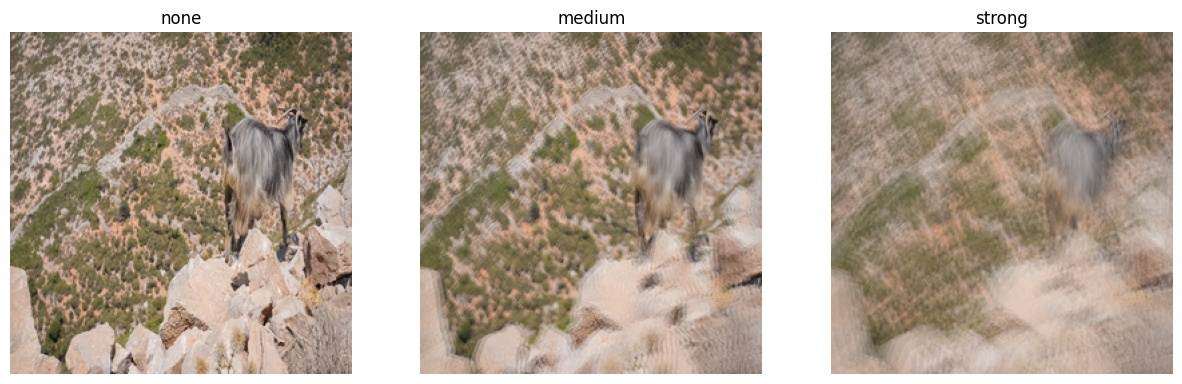

In [ ]:
import matplotlib.pyplot as plt

frame_idx = 45  # ein Frame in der Mitte
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, level_name in zip(axes, BLUR_LEVELS.keys()):
    blurred_frames = blur_video(frames_uint8, BLUR_LEVELS[level_name])
    ax.imshow(blurred_frames[frame_idx])
    ax.set_title(level_name)
    ax.axis("off")
plt.show()

Bestätigungscheck

In [ ]:
for level_name, window in BLUR_LEVELS.items():
    blurred_frames = blur_video(frames_uint8, window)
    blurred_video = (blurred_frames.astype(np.float32) / 255.0 * 2 - 1)[None]
    tracks, visibles = run_tapnext(blurred_video, batch['query_points'])

    pred_occluded_rate = np.logical_not(visibles).mean()
    print(level_name, "vorhergesagter Occluded-Anteil:", pred_occluded_rate)

print("Ground-Truth Occluded-Anteil:", batch['occluded'].mean())

none vorhergesagter Occluded-Anteil: 0.05555555555555555
medium vorhergesagter Occluded-Anteil: 0.82
strong vorhergesagter Occluded-Anteil: 0.74
Ground-Truth Occluded-Anteil: 0.0


In [ ]:
%%time
# @title Quantitative results

davis_dataset = evaluation_datasets.create_davis_dataset(
    davis_points_path='./tapvid_davis/tapvid_davis.pkl',
    query_mode='first',
    full_resolution=False,
    resolution=(256, 256),
)

scores = []
for i, sample in enumerate(davis_dataset):
  batch = sample['davis']
  print('video', i, jax.tree_util.tree_map(lambda x: x.shape, batch))
  tracks, visibles, state = [], [], None
  for t in range(0, batch['video'].shape[1]):
    pred_tracks, pred_visible, state = forward(
        params, batch['video'][:, t], batch['query_points'], t, state
    )
    tracks.append(pred_tracks)
    visibles.append(pred_visible)
  tracks = np.stack(tracks, axis=2)[..., ::-1]
  visibles = np.stack(visibles, axis=2).squeeze(-1)

  scalars = evaluation_datasets.compute_tapvid_metrics(
      batch['query_points'],
      batch['occluded'],
      batch['target_points'],
      np.logical_not(visibles),
      tracks,
      query_mode='first',
  )
  scalars = jax.tree.map(lambda x: np.array(np.sum(x, axis=0)), scalars)
  scores.append(scalars)

print(np.mean([scores[k]['average_jaccard'] for k in range(len(scores))]))
print(np.mean([scores[k]['occlusion_accuracy'] for k in range(len(scores))]))
print(
    np.mean(
        [scores[k]['average_pts_within_thresh'] for k in range(len(scores))]
    )
)

video 0 {'occluded': (1, 5, 90), 'query_points': (1, 5, 3), 'target_points': (1, 5, 90, 2), 'video': (1, 90, 256, 256, 3)}
video 1 {'occluded': (1, 20, 75), 'query_points': (1, 20, 3), 'target_points': (1, 20, 75, 2), 'video': (1, 75, 256, 256, 3)}
video 2 {'occluded': (1, 25, 40), 'query_points': (1, 25, 3), 'target_points': (1, 25, 40, 2), 'video': (1, 40, 256, 256, 3)}
video 3 {'occluded': (1, 25, 84), 'query_points': (1, 25, 3), 'target_points': (1, 25, 84, 2), 'video': (1, 84, 256, 256, 3)}
video 4 {'occluded': (1, 25, 52), 'query_points': (1, 25, 3), 'target_points': (1, 25, 52, 2), 'video': (1, 52, 256, 256, 3)}
video 5 {'occluded': (1, 25, 50), 'query_points': (1, 25, 3), 'target_points': (1, 25, 50, 2), 'video': (1, 50, 256, 256, 3)}
video 6 {'occluded': (1, 25, 34), 'query_points': (1, 25, 3), 'target_points': (1, 25, 34, 2), 'video': (1, 34, 256, 256, 3)}
video 7 {'occluded': (1, 25, 99), 'query_points': (1, 25, 3), 'target_points': (1, 25, 99, 2), 'video': (1, 99, 256, 256,

Drive mounten:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/ba_results', exist_ok=True)

Mounted at /content/drive


Voller Durchlauf

In [ ]:
import pandas as pd

results_path = "/content/drive/MyDrive/ba_results/tapnext_all_videos.csv"
all_results = []

davis_dataset_full = evaluation_datasets.create_davis_dataset(
    davis_points_path='./tapvid_davis/tapvid_davis.pkl',
    query_mode='first',
    full_resolution=False,
    resolution=(256, 256),
)

for video_idx, sample in enumerate(davis_dataset_full):
    batch_i = sample['davis']
    raw_video = batch_i['video']
    frames_uint8 = ((raw_video[0] + 1) / 2 * 255).astype(np.uint8)

    for level_name, window in BLUR_LEVELS.items():
        blurred_frames = blur_video(frames_uint8, window)
        blurred_video = (blurred_frames.astype(np.float32) / 255.0 * 2 - 1)[None]

        tracks, visibles = run_tapnext(blurred_video, batch_i['query_points'])

        scalars = evaluation_datasets.compute_tapvid_metrics(
            batch_i['query_points'], batch_i['occluded'], batch_i['target_points'],
            np.logical_not(visibles), tracks, query_mode='first',
        )
        scalars = jax.tree.map(lambda x: np.array(np.sum(x, axis=0)), scalars)

        row = {"video": video_idx, "model": "TapNext", "blur": level_name}
        row.update({k: float(v) * 100 for k, v in scalars.items()})
        all_results.append(row)

    pd.DataFrame(all_results).to_csv(results_path, index=False)
    print(f"Video {video_idx}/29 fertig")

print("Alle 30 Videos abgeschlossen.")
df = pd.DataFrame(all_results)
print(df.groupby("blur")[["average_jaccard", "occlusion_accuracy", "average_pts_within_thresh"]].mean())

Video 0/29 fertig
Video 1/29 fertig
Video 2/29 fertig
Video 3/29 fertig
Video 4/29 fertig
Video 5/29 fertig
Video 6/29 fertig
Video 7/29 fertig
Video 8/29 fertig
Video 9/29 fertig
Video 10/29 fertig
Video 11/29 fertig
Video 12/29 fertig
Video 13/29 fertig
Video 14/29 fertig
Video 15/29 fertig
Video 16/29 fertig
Video 17/29 fertig
Video 18/29 fertig
Video 19/29 fertig
Video 20/29 fertig
Video 21/29 fertig
Video 22/29 fertig
Video 23/29 fertig
Video 24/29 fertig
Video 25/29 fertig
Video 26/29 fertig
Video 27/29 fertig
Video 28/29 fertig
Video 29/29 fertig
Alle 30 Videos abgeschlossen.
        average_jaccard  occlusion_accuracy  average_pts_within_thresh
blur                                                                  
medium        42.324421           77.255704                  57.304836
none          66.708108           91.340181                  79.559260
strong        19.219172           62.053555                  30.756450


Video 1 laden:

In [ ]:
davis_v1 = evaluation_datasets.create_davis_dataset(
    davis_points_path='./tapvid_davis/tapvid_davis.pkl',
    query_mode='first',
    full_resolution=False,
    resolution=(256, 256),
)
for i, sample in enumerate(davis_v1):
    if i == 1:
        batch = sample['davis']
        break

frames_uint8 = ((batch['video'][0] + 1) / 2 * 255).astype(np.uint8)

Dann die Trajektorien für TapNext speichern:

In [ ]:
blurred_frames = blur_video(frames_uint8, BLUR_LEVELS["strong"])
blurred_video = (blurred_frames.astype(np.float32) / 255.0 * 2 - 1)[None]
tracks, visibles = run_tapnext(blurred_video, batch['query_points'])

import numpy as np
np.save("/content/drive/MyDrive/ba_results/tapnext_traj_video1_strong.npy", tracks[0])